#### Laurent Jutras-Dubé
  
<br>

This Jupyter notebook reproduces the simulations shown in Figure 2 of the paper titled "Optogenetic-Programmable Human Embryo Models Elucidate the Interplay Between Tissue Architecture and BMP4 Signaling at the Onset of Gastrulation" by Riccardo De Santis, Laurent Jutras-Dubé, Sophia Bourdrel, Eleni Rice, Francesco Piccolo, and Ali H. Brivanlou.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import ode
from hexalattice.hexalattice import create_hex_grid
from matplotlib import colors

In [3]:
def integrate(PDEs, n_var, param):
    
    # Integrator and parameters
    integrator = ode(PDEs)
    integrator.set_integrator('lsoda', with_jacobian=False, rtol=1e-4, nsteps=1000)
    integrator.set_f_params(param)
    
    # Initial conditions
    times = param["t"] 
    init_cond = np.zeros(n_var*len(param["x"]))
    integrator.set_initial_value(init_cond, times[0])
    results = [init_cond]
    
    # Integration
    for t in times[1:]:
        integrator.integrate(t)
        if (integrator.successful):
            results.append(integrator.y)
        else:
            print("An error occurred during the integration.")
            break
           
    # Output
    if len(times) > 1:    return np.array(results)
    else:    return results[0]



def compute_BMP4_prod(param):

    x, x_L, s = param["x"], param["x_L"], param["s_B"]
    prod_B = 0.5*np.tanh((x+x_L)/s)+0.5
    prod_B[x>0] = (0.5*np.tanh((-x+x_L)/s)+0.5)[x>0]

    return param["p_B"]*prod_B



def PDEs_FIG2(t, var, param):
    
    # Position
    x = param["x"]
    dx = x[1]-x[0]

    # BMP4, NOGGIN, NODAL 
    var[var < 0.] = 0.
    B = var[:len(x)]
    N = var[len(x):2*len(x)]
    O = var[2*len(x):]

    # Free BMP4
    B_f = B/(1.+param["a"]*N)
    
    # pSMAD1
    K_1, n_1 = param["max_K1"], param["n_S1"]
    S_1 = B_f**n_1/(B_f**n_1+K_1**n_1)
    
    # Diffusion terms
    diff_B, diff_N, diff_O = [np.zeros(len(x)) for k in range(3)]
    diff_B[1:-1] = B[:-2]-2.*B[1:-1]+B[2:]
    diff_N[1:-1] = N[:-2]-2.*N[1:-1]+N[2:]
    diff_O[1:-1] = O[:-2]-2.*O[1:-1]+O[2:]

    # Boundary conditions
    diff_B[0], diff_B[-1] = 2.*(B[1]-B[0]), 2.*(B[-2]-B[-1])
    diff_N[0], diff_N[-1] = 2.*(N[1]-N[0]), 2.*(N[-2]-N[-1])
    diff_O[0], diff_O[-1] = 2.*(O[1]-O[0]), 2.*(O[-2]-O[-1])

    # PDEs
    d_B = param["prod_B"]+param["D_B"]*diff_B/dx**2-param["l_B"]*B
    d_N = param["p_N"]*S_1+param["D_N"]*diff_N/dx**2-param["l_N"]*N
    d_O = param["p_O"]*S_1+param["D_O"]*diff_O/dx**2-param["l_O"]*O
    
    return np.concatenate((d_B, d_N, d_O))


def sim_FIG2(param):

    # Position
    x = param["x"]
    
    # BMP4, NOGGIN, NODAL
    results = integrate(PDEs_FIG2, 3, param)
    results[results < 0.] = 0.
    B = results[:,:len(x)]
    N = results[:,len(x):2*len(x)]
    O = results[:,2*len(x):]
    
    # Free BMP4
    B_f = B/(1.+param["a"]*N)
    
    # pSMAD1
    K_1, n_1 = param["max_K1"], param["n_S1"]
    S_1 = B_f**n_1/(B_f**n_1+K_1**n_1)
    
    # pSMAD2
    n_2, K_2 = param["n_S2"], param["K_S2"]
    S_2 = O**n_2/(O**n_2+K_2**n_2)
    
    # ISL1
    n_f, K_f = param["n_f"], param["K_f"]
    ISL1 = S_1**n_f/(S_1**n_f+K_f**n_f)
    
    # BRA
    BRA = S_2**n_f/(S_2**n_f+K_f**n_f)
    BRA *= K_f**n_f/(ISL1**n_f+K_f**n_f)
    
    # SOX2
    SOX2 = K_f**n_f/(S_1**n_f+K_f**n_f)
    SOX2 *= K_f**n_f/(BRA**n_f+K_f**n_f)

    return x, np.array([B,N,O,B_f]), np.array([S_1,S_2]), np.array([SOX2,ISL1,BRA])

In [4]:
param = {

    # BMP4
    "p_B"    : 2100.,
    "D_B"    : 3700.,
    "l_B"    : 0.503,
    "s_B"    : 46.5,
    "prod_B" : 1.,
    
    # NOGGIN
    "p_N" : 0.01,
    "D_N" : 400.,
    "l_N" : 0.04,
    "a"   : 130.,
    
    # NODAL
    "p_O" : 15.,
    "D_O" : 4e4,
    "l_O" : 70.,

    # pSMAD1
    "n_S1"   : 1.4,
    "max_K1" : 35.,
    "min_K1" : 0.1,
    "n_K1"   : 25.,

    # pSMAD2
    "n_S2" : 4.2,
    "K_S2" : 0.04,

    # Fates
    "n_f" : 8.,
    "K_f" : 0.5,
    
    # Time points & positions
    "t"   : np.linspace(0.1, 48., 500),
    "x"   : np.linspace(-3700., 3700., 1000),
    "x_L" : 250.
    
}

# Scale factors
alpha_B = param["p_B"]/param["l_B"]
alpha_N = param["p_N"]/param["l_N"]
alpha_O = param["p_O"]/param["l_O"]

<br>

Simulations

In [5]:
param["prod_B"] = compute_BMP4_prod(param)
x, ligands, TFs, fates = sim_FIG2(param)

<br>

Figure 2D-F

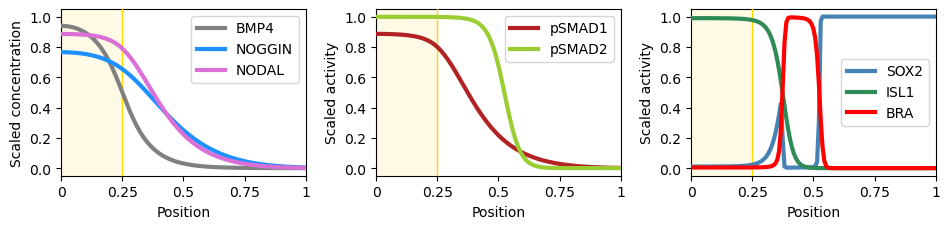

In [6]:
fig, ax = plt.subplots(ncols=3, figsize=[9.6, 2.4])

# Ligands
ax[0].plot(x, ligands[0,-1]/alpha_B, c='grey', lw=3, label='BMP4', zorder=8)
ax[0].plot(x, ligands[1,-1]/alpha_N, c='dodgerblue', lw=3, label='NOGGIN', zorder=8)
ax[0].plot(x, ligands[2,-1]/alpha_O, c='orchid', lw=3, label='NODAL', zorder=8)

# TFs
ax[1].plot(x, TFs[0,-1], c='firebrick', lw=3, label='pSMAD1', zorder=8)
ax[1].plot(x, TFs[1,-1], c='yellowgreen', lw=3, label='pSMAD2', zorder=8)

# Fates
ax[2].plot(x, fates[0,-1], c='steelblue', lw=3, label='SOX2', zorder=8)
ax[2].plot(x, fates[1,-1], c='seagreen', lw=3, label='ISL1', zorder=8)
ax[2].plot(x, fates[2,-1], c='red', lw=3, label='BRA', zorder=8)

# Axes, legend, light domain
x_L = param["x_L"]
for k in range(3):
    ax[k].set_xlabel('Position')
    ax[k].set_ylabel('Scaled activity')
    ax[k].set_xlim([0., 800.])
    ax[k].set_ylim([-0.05, 1.05])
    ax[k].set_xticks([0.,250.,500.,750.,1000.])
    ax[k].set_xticklabels([0,0.25,0.5,0.75,1])
    ax[k].fill_between([0.,x_L], [-0.05, -0.05], [1.05, 1.05], color='gold', alpha=0.1)
    ax[k].plot([x_L,x_L], [-0.05, 1.05], c='gold', lw=1., zorder=6)
    leg = ax[k].legend()
    leg.set_zorder(12)
ax[0].set_ylabel('Scaled concentration')
fig.tight_layout()

<br>

Figure 2C

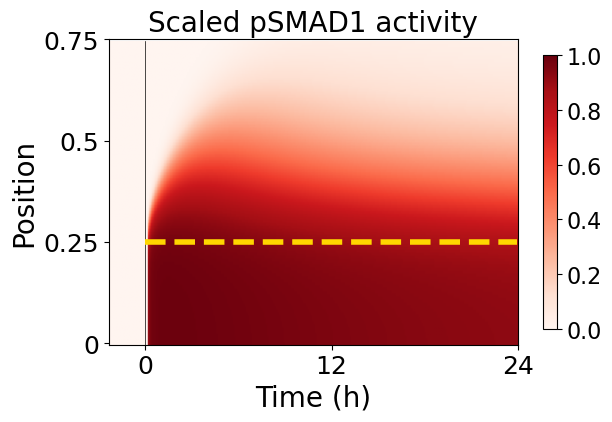

In [7]:
fig, ax = plt.subplots(figsize=[6.4, 6.4])

# pSMAD1 kymograph
pSMAD1_kymo = np.concatenate((np.zeros((len(TFs[0].T),25)), TFs[0].T), axis=1)
norm = colors.Normalize(vmin=0., vmax=1.)
kymo_plot = ax.imshow(pSMAD1_kymo[500:602,:274], norm=norm, cmap='Reds', aspect=2, origin='lower')

# Colorbar
cb = fig.colorbar(kymo_plot, ax=ax, shrink=0.45)
cb.ax.tick_params(labelsize=16)

# Light domain
ax.plot([24., 24.], [-0.5, 101.5], c='k', lw=0.5)
ax.plot([24., 273.5], [34., 34.], c='gold', ls='--', lw=4)

# Axes
ax.set_title('Scaled pSMAD1 activity', fontsize=20)
ax.set_ylabel('Position', fontsize=20)
ax.set_yticks([0., 34., 68., 102.])
ax.set_yticklabels([0, 0.25, 0.5, 0.75], fontsize=18)
ax.set_xlabel('Time (h)', fontsize=20)
ax.set_xticks([24., 149., 274.])
ax.set_xticklabels([0, 12, 24], fontsize=18)

fig.tight_layout()

<br>

Graphical abstract

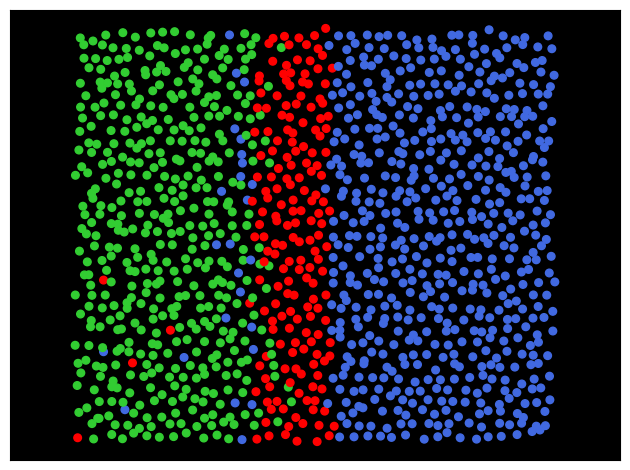

In [8]:
# Hexagonal cell grid
n = 35
hex, _ = create_hex_grid(nx=n, ny=n, do_plot=False)
tile_x = hex[:, 0]+n*0.5
tile_y = hex[:, 1]

# Cell fate choice
s = n/1000.
prob = fates[:,-1].copy()
prob /= np.sum(prob, axis=0)
prob_i = np.array([np.where(np.abs(x*s-tile_x[k]) == np.min(np.abs(x*s-tile_x[k])))[0][0] for k in range(len(tile_x))])
c = np.array([np.random.choice(['royalblue', 'limegreen', 'red'], 1, p=prob[:,prob_i[k]])[0] for k in range(len(tile_x))])

# Cell position noise
tile_x += np.random.normal(loc=0., scale=0.2, size=len(tile_x))
tile_y += np.random.normal(loc=0., scale=0.2, size=len(tile_y))

# Figure
fig, ax = plt.subplots()
ax.scatter(tile_x, tile_y, s=30, c=c)
ax.axis('equal')
ax.set_facecolor('k')
ax.set_xticks([])
ax.set_yticks([])
fig.tight_layout()